In [2]:
import os
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import DummyVecEnv

save_path = "outputs/checkpoints"
os.makedirs(save_path, exist_ok=True)

def make_env(env_id: str, seed: int) -> gym.Env:
    env = gym.make(env_id)
    env.reset(seed=seed)
    return env


=== CartPole seed 0 ===


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\stable_baselines3\common\evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


512 steps: 109.4 +/- 42.4
1024 steps: 103.0 +/- 38.6
1536 steps: 108.2 +/- 37.2
2048 steps: 129.8 +/- 63.2
2560 steps: 131.1 +/- 42.6
3072 steps: 118.5 +/- 32.8
3584 steps: 99.0 +/- 31.0
4096 steps: 116.0 +/- 36.6
4608 steps: 107.7 +/- 39.4
5120 steps: 86.6 +/- 31.6
5632 steps: 95.7 +/- 25.7
6144 steps: 107.5 +/- 42.4
6656 steps: 104.0 +/- 30.1
7168 steps: 136.5 +/- 51.9
7680 steps: 131.0 +/- 45.1
8192 steps: 149.2 +/- 49.1
8704 steps: 147.1 +/- 52.6
9216 steps: 150.6 +/- 42.7
9728 steps: 198.3 +/- 80.9
10240 steps: 181.8 +/- 73.4
10752 steps: 198.4 +/- 86.0
11264 steps: 218.7 +/- 84.5
11776 steps: 208.6 +/- 58.5
12288 steps: 211.7 +/- 71.5
12800 steps: 258.9 +/- 68.4
13312 steps: 319.2 +/- 125.9
13824 steps: 314.6 +/- 119.4
14336 steps: 324.2 +/- 98.2
>>> pi2 saved at 14336 steps: 324.2 +/- 98.2
14848 steps: 477.0 +/- 44.9
15360 steps: 500.0 +/- 0.0
>>> pi1 saved at 15360 steps: 500.0 +/- 0.0
15872 steps: 436.8 +/- 84.1
16384 steps: 500.0 +/- 0.0
16896 steps: 500.0 +/- 0.0
17408 steps

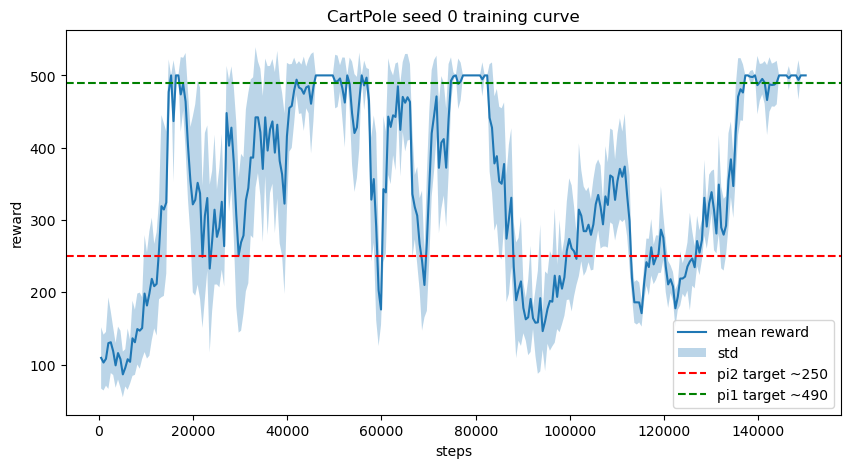


Done! Saved policies:
  pi1_cartpole_seed0.zip  |  pi2_cartpole_seed0.zip


In [3]:
target_pi2_reward = 250
target_pi1_reward = 490
seed = 0
pi2_steps = 14336
max_steps = 150_000

checkpoint_interval = 512

print(f"\n=== CartPole seed {seed} ===")

rng = np.random.default_rng(seed)
env_train = DummyVecEnv([lambda: make_env("CartPole-v1", seed=int(rng.integers(0, 1000000)))])
n_eval_episodes = 20
env_eval  = DummyVecEnv([lambda: make_env("CartPole-v1", seed=int(rng.integers(0, 1000000))) for _ in range(n_eval_episodes)])

steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=seed,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)

total_steps = 0
pi2_saved = False
pi1_saved = False

for _ in range(0, max_steps, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=n_eval_episodes, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    # save pi2 at target steps
    if total_steps == pi2_steps and not pi2_saved:
        model.save(os.path.join(save_path, f"pi2_cartpole_seed{seed}"))
        print(f">>> pi2 saved at {total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")
        pi2_saved = True

    # save pi1 once policy is excellent
    if mean_reward >= target_pi1_reward and not pi1_saved:
        model.save(os.path.join(save_path, f"pi1_cartpole_seed{seed}"))
        print(f">>> pi1 saved at {total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")
        pi1_saved = True

    # if pi1_saved:
    #     print(f"Both policies saved for seed {seed}, stopping")
    #     break
    # Do not stop immediately after pi1 is saved.
    # Continue training to get a smoother / longer graph.

# pick the best checkpoint for pi2 on the next run
if steps_log:
    mean_array = np.asarray(mean_log)
    best_pi2_idx = int(np.argmin(np.abs(mean_array - target_pi2_reward)))
    best_pi2_steps = steps_log[best_pi2_idx]
    best_pi2_reward = mean_log[best_pi2_idx]
    print(
        f"Suggested pi2_steps for the next run: {best_pi2_steps} "
        f"(mean reward {best_pi2_reward:.1f}, target {target_pi2_reward})"
    )
    pi2_steps = best_pi2_steps

# plot
plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(target_pi2_reward, color="red",   linestyle="--", label=f"pi2 target ~{target_pi2_reward}")
plt.axhline(target_pi1_reward, color="green", linestyle="--", label=f"pi1 target ~{target_pi1_reward}")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title(f"CartPole seed {seed} training curve")
plt.legend()
plt.show()

print("\nDone! Saved policies:")
print(f"  pi1_cartpole_seed{seed}.zip  |  pi2_cartpole_seed{seed}.zip")


=== Pendulum seed 0 ===


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\stable_baselines3\common\evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


4096 steps: -1087.4 +/- 186.2
8192 steps: -1145.3 +/- 307.1
12288 steps: -1222.1 +/- 316.3
16384 steps: -1299.2 +/- 288.5
20480 steps: -1302.1 +/- 299.2
24576 steps: -1169.1 +/- 317.4
28672 steps: -1105.4 +/- 276.0
32768 steps: -1162.2 +/- 245.2
36864 steps: -1262.7 +/- 310.1
40960 steps: -1221.5 +/- 282.7
45056 steps: -1190.0 +/- 248.1
49152 steps: -1114.8 +/- 198.9
53248 steps: -1150.4 +/- 299.7
57344 steps: -1080.2 +/- 202.0
61440 steps: -1126.4 +/- 293.3
65536 steps: -1320.7 +/- 276.6
69632 steps: -1195.3 +/- 290.3
73728 steps: -1205.8 +/- 304.0
77824 steps: -1174.8 +/- 317.1
81920 steps: -1144.7 +/- 344.7
86016 steps: -1089.3 +/- 305.2
90112 steps: -1247.2 +/- 314.0
94208 steps: -1123.2 +/- 263.3
98304 steps: -1200.7 +/- 249.3
102400 steps: -1113.5 +/- 311.8
106496 steps: -1222.2 +/- 296.2
110592 steps: -1201.2 +/- 293.4
114688 steps: -1278.4 +/- 293.0
118784 steps: -1151.4 +/- 264.6
122880 steps: -1106.7 +/- 254.4
126976 steps: -1009.7 +/- 241.5
131072 steps: -1134.0 +/- 196.9
13

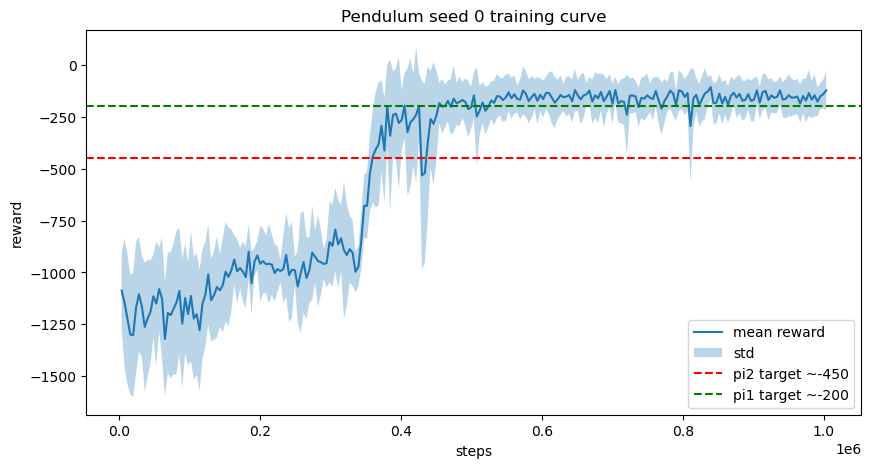


Done! Saved policies:
  pi1_pendulum_seed0.zip  |  pi2_pendulum_seed0.zip


In [4]:
target_pi2_reward = -450
target_pi1_reward = -200
checkpoint_interval = 4096
max_steps = 1_000_000

seed = 0
pi2_steps = 360448

print(f"\n=== Pendulum seed {seed} ===")

rng = np.random.default_rng(seed)
env_train = DummyVecEnv([lambda: make_env("Pendulum-v1", seed=int(rng.integers(0, 1000000)))])
n_eval_episodes = 20
env_eval  = DummyVecEnv([lambda: make_env("Pendulum-v1", seed=int(rng.integers(0, 1000000))) for _ in range(n_eval_episodes)])

steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy", env_train, verbose=0, device="cpu", seed=seed,
    learning_rate=3e-4, n_steps=2048, batch_size=64,
    n_epochs=5, ent_coef=0.01, gamma=0.99,
)

total_steps = 0
pi2_saved = False
pi1_saved = False

for _ in range(0, 1_000_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=n_eval_episodes, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    # save pi2 at target steps
    if total_steps >= pi2_steps and not pi2_saved:
        model.save(os.path.join(save_path, f"pi2_pendulum_seed{seed}"))
        print(f">>> pi2 saved at {total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")
        pi2_saved = True

    # save pi1 once policy is excellent
    if mean_reward >= target_pi1_reward and not pi1_saved:
        model.save(os.path.join(save_path, f"pi1_pendulum_seed{seed}"))
        print(f">>> pi1 saved at {total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")
        pi1_saved = True

    # Continue training after pi1 is saved to get a longer curve
    # if pi1_saved:
    #     print(f"Both policies saved for seed {seed}, stopping")
    #     break

# pick the best checkpoint for pi2 on the next run
if steps_log:
    mean_array = np.asarray(mean_log)
    best_pi2_idx = int(np.argmin(np.abs(mean_array - target_pi2_reward)))
    best_pi2_steps = steps_log[best_pi2_idx]
    best_pi2_reward = mean_log[best_pi2_idx]
    print(
        f"Suggested pi2_steps for the next run: {best_pi2_steps} "
        f"(mean reward {best_pi2_reward:.1f}, target {target_pi2_reward})"
    )
    pi2_steps = best_pi2_steps

# plot
plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(target_pi2_reward, color="red",   linestyle="--", label=f"pi2 target ~{target_pi2_reward}")
plt.axhline(target_pi1_reward, color="green", linestyle="--", label=f"pi1 target ~{target_pi1_reward}")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title(f"Pendulum seed {seed} training curve")
plt.legend()
plt.show()

print("\nDone! Saved policies:")
print(f"  pi1_pendulum_seed{seed}.zip  |  pi2_pendulum_seed{seed}.zip")